# Netflix Content Analysis
### Exploratory Data Analysis | Samuel Oluwadamilare Daramola
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Dataset:** Netflix Movies and TV Shows (5837 titles)

---
## Objective
To analyse Netflix's content catalogue and uncover patterns in content type, genre trends, country of origin, and audience rating distribution — with a focus on identifying strategic insights relevant to content planning and platform growth.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 120
})

NETFLIX_RED = '#E50914'
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load and Inspect the Dataset

In [5]:
df = pd.read_csv('netflix_titles_nov_2019.csv')
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = pd.to_numeric(df['date_added'].dt.year, errors='coerce').astype('Int64')

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (5837, 13)
Columns: ['show_id', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description', 'type', 'year_added']


,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type,year_added
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,2019-11-30,2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show,2019
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,2019-11-30,2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie,2019
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,2019-11-30,2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie,2019
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium",2019-11-29,2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie,2019
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaT,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show,<NA>


## 2. Dataset Overview & Missing Values


In [6]:
print("=== Basic Info ===")
print(f"Total Titles: {len(df):,}")
print(f"Date Range: {df['year_added'].min():.0f} – {df['year_added'].max():.0f}")
print()
print("=== Content Type Split ===")
print(df['type'].value_counts())
print()
print("=== Missing Values ===")
print(df.isnull().sum())

=== Basic Info ===
Total Titles: 5,837
Date Range: 2008 – 2019

=== Content Type Split ===
type
Movie      3939
TV Show    1898
Name: count, dtype: int64

=== Missing Values ===
show_id            0
title              0
director        1901
cast             556
country          427
date_added       642
release_year       0
rating            10
duration           0
listed_in          0
description        0
type               0
year_added       642
dtype: int64


## 3. Movies vs TV Shows

In [7]:
type_counts = df['type'].value_counts()

fig_pie = go.Figure(go.Pie(
    labels=type_counts.index,
    values=type_counts.values,
    marker_colors=[NETFLIX_RED, '#CFC5C5'],
    textinfo='percent+label'
))
fig_pie.update_layout(title='Content Type Split', template='plotly_white')
fig_pie.show()

yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
movie_series = yearly.get('Movie', pd.Series(0, index=yearly.index))
tv_series = yearly.get('TV Show', pd.Series(0, index=yearly.index))

fig_bar = go.Figure()
fig_bar.add_trace(go.Bar(x=yearly.index, y=movie_series.values, name='Movie', marker_color=NETFLIX_RED))
fig_bar.add_trace(go.Bar(x=yearly.index, y=tv_series.values, name='TV Show', marker_color='#221F1F'))
fig_bar.update_layout(
    title='Content Added Per Year by Type',
    xaxis_title='Year',
    yaxis_title='Number of Titles',
    barmode='group',
    template='plotly_white'
)
fig_bar.show()

print(f"\nFINDING: Netflix's catalogue is {type_counts['Movie']/len(df)*100:.1f}% Movies and {type_counts['TV Show']/len(df)*100:.1f}% TV Shows.")
print(f"TV Show additions grew faster than Movies from 2015 onward, reflecting a shift toward serialised content.")


FINDING: Netflix's catalogue is 67.5% Movies and 32.5% TV Shows.
TV Show additions grew faster than Movies from 2015 onward, reflecting a shift toward serialised content.


## 4. Genre Distribution & Trends


In [16]:
# Split multi-genre strings into lists
df['genre_list'] = df['listed_in'].str.split(', ')

# Explode so each genre becomes its own row
df_exploded = df.explode('genre_list')
genre_counts = df_exploded['genre_list'].value_counts()
top15 = genre_counts.head(15)
print(f"\nTop 15 Genres:\n{top15}")

top10 = genre_counts.head(10)
fig_genres = go.Figure(go.Bar(
    x=top10.values[::-1],
    y=top10.index[::-1],
    orientation='h',
    marker_color=[NETFLIX_RED if i == 0 else '#888888' for i in range(len(top10))][::-1],
    text=top10.values[::-1],
    textposition='outside'
))
fig_genres.update_layout(
    title='Top 10 Genres on Netflix',
    xaxis_title='Number of Titles',
    yaxis_title='Genre',
    template='plotly_white'
)
fig_genres.show()

top_genre = genre_counts.index[0]
top_count = genre_counts.values[0]
pct = top_count / len(df) * 100
print(f"FINDING: {top_genre} is the dominant genre with {top_count} titles ({pct:.1f}% of catalogue).")


Top 15 Genres:
genre_list
International Movies        1797
Dramas                      1488
Comedies                     992
International TV Shows       966
Documentaries                658
TV Dramas                    574
Action & Adventure           532
Independent Movies           516
TV Comedies                  425
Crime TV Shows               355
Thrillers                    353
Children & Family Movies     340
Romantic Movies              338
Kids' TV                     313
Stand-Up Comedy              273
Name: count, dtype: int64


FINDING: International Movies is the dominant genre with 1797 titles (30.8% of catalogue).


## 5. Genre Split — Movies vs TV Shows

In [18]:
country_counts = df['country'].value_counts().head(10)

fig_countries = go.Figure(go.Bar(
    x=country_counts.index,
    y=country_counts.values,
    marker_color=[NETFLIX_RED if i == 0 else '#B81D24' if i == 1 else '#AAAAAA' for i in range(len(country_counts))]
))
fig_countries.update_layout(
    title='Top 10 Content-Producing Countries on Netflix',
    xaxis_title='Country',
    yaxis_title='Number of Titles',
    template='plotly_white',
    xaxis_tickangle=-35
)
fig_countries.show()

country_geo = country_counts.reset_index()
country_geo.columns = ['Country', 'Titles']
country_geo['Country'] = country_geo['Country'].replace({
    'United States': 'United States of America',
    'United Kingdom': 'United Kingdom'
})

fig_geo = go.Figure(go.Choropleth(
    locations=country_geo['Country'],
    z=country_geo['Titles'],
    locationmode='country names',
    colorscale='Reds',
    marker_line_color='white',
    marker_line_width=0.5,
    colorbar_title='Titles'
))
fig_geo.update_layout(
    title='Geographic Distribution of Netflix Content',
    geo=dict(showframe=False, projection_type='equirectangular'),
    template='plotly_white'
)
fig_geo.show()

us_pct = country_counts['United States'] / len(df) * 100
print(f"FINDING: The United States dominates Netflix's catalogue with {country_counts['United States']} titles ({us_pct:.1f}%).")
print(f"India ranks 2nd with {country_counts.get('India', 0)} titles — reflecting Netflix's major investment in Bollywood and Indian originals.")
print(f"African countries (incl. Nigeria) are underrepresented, suggesting an opportunity for regional content expansion.")

FINDING: The United States dominates Netflix's catalogue with 1907 titles (32.7%).
India ranks 2nd with 697 titles — reflecting Netflix's major investment in Bollywood and Indian originals.
African countries (incl. Nigeria) are underrepresented, suggesting an opportunity for regional content expansion.


## 6. Content by Country

In [17]:
rating_counts = df['rating'].value_counts().head(8)

fig_ratings = go.Figure(go.Bar(
    x=rating_counts.index,
    y=rating_counts.values,
    marker_color=go.Figure().data[0].marker.color if False else None
))
fig_ratings.update_traces(marker_color=[NETFLIX_RED if i == 0 else '#B81D24' if i == 1 else '#CC4C4C' if i == 2 else '#E28C8C' if i == 3 else '#F2B6B6' for i in range(len(rating_counts))])
fig_ratings.update_layout(
    title='Distribution of Content Ratings',
    xaxis_title='Rating',
    yaxis_title='Number of Titles',
    template='plotly_white'
)
fig_ratings.show()

top_rating = rating_counts.index[0]
top_pct = rating_counts.values[0] / len(df) * 100
mature_pct = (rating_counts.get('TV-MA', 0) + rating_counts.get('R', 0)) / len(df) * 100
print(f"FINDING: {top_rating} is the most common rating ({top_pct:.1f}% of content).")
print(f"Mature-rated content (TV-MA + R) makes up {mature_pct:.1f}% of the catalogue — Netflix clearly targets adult audiences primarily.")

FINDING: TV-MA is the most common rating (33.2% of content).
Mature-rated content (TV-MA + R) makes up 40.7% of the catalogue — Netflix clearly targets adult audiences primarily.


## 7. Audience Rating Distribution

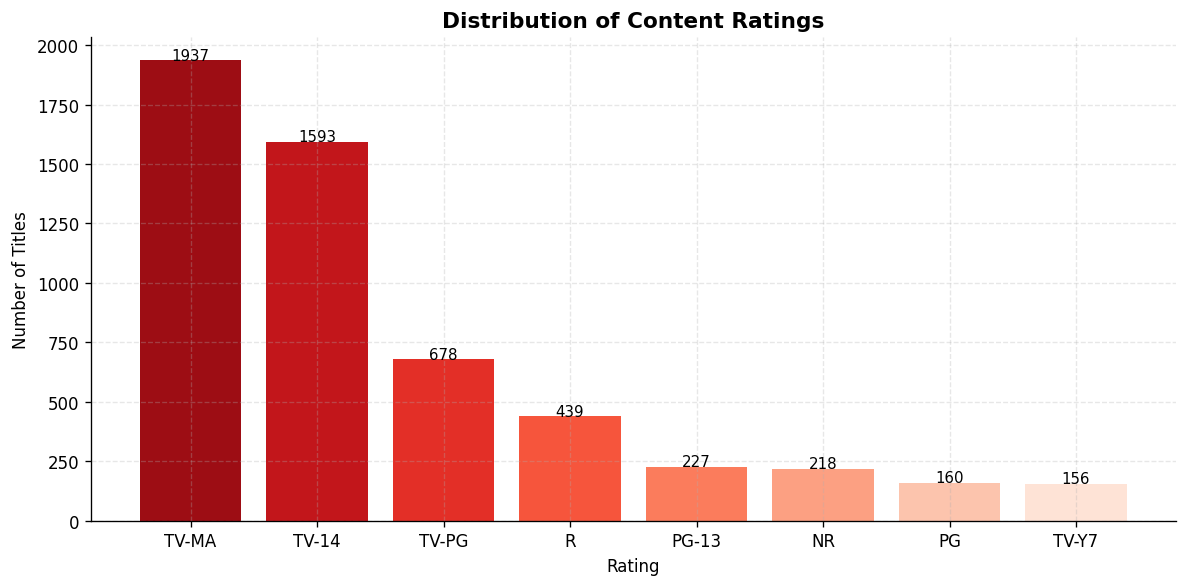

FINDING: TV-MA is the most common rating (33.2% of content).
Mature-rated content (TV-MA + R) makes up 40.7% of the catalogue — Netflix clearly targets adult audiences primarily.


In [12]:
rating_counts = df['rating'].value_counts().head(8)

fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette("Reds_r", len(rating_counts))
bars = ax.bar(rating_counts.index, rating_counts.values, color=palette, edgecolor='none')
ax.set_title('Distribution of Content Ratings', fontsize=13, fontweight='bold')
ax.set_xlabel('Rating'); ax.set_ylabel('Number of Titles')
for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val),
            ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_ratings.png', dpi=150, bbox_inches='tight')
plt.show()

top_rating = rating_counts.index[0]
top_pct = rating_counts.values[0] / len(df) * 100
mature_pct = (rating_counts.get('TV-MA', 0) + rating_counts.get('R', 0)) / len(df) * 100
print(f"FINDING: {top_rating} is the most common rating ({top_pct:.1f}% of content).")
print(f"Mature-rated content (TV-MA + R) makes up {mature_pct:.1f}% of the catalogue — Netflix clearly targets adult audiences primarily.")